In [1]:
import wandb
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.pyplot import cm
import re
import math
import matplotlib.gridspec as gridspec
import json
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import pandas as pd
api = wandb.Api(timeout=19)

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/mila/r/roy.eyono/.netrc.


In [2]:
# Fetch runs for a specific project
def fetch_runs(api, entity, project_name, filters, order=None):
    if order:
        runs = api.runs(f"{entity}/{project_name}", filters=filters, order=order, lazy=False)
    else:
        runs = api.runs(f"{entity}/{project_name}", filters=filters)
    #print(f"Runs for project '{project_name}':")
    return runs

In [3]:
def same_config(config1, config2, keys=['normtype']):
    for key in keys:
        if config1[key] != config2[key]:
            return False
    return True

/tmp/ipykernel_1312898/3802557133.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  trunc_bone = truncate_colormap(cm.get_cmap("bone"), 0.4, 0.9)


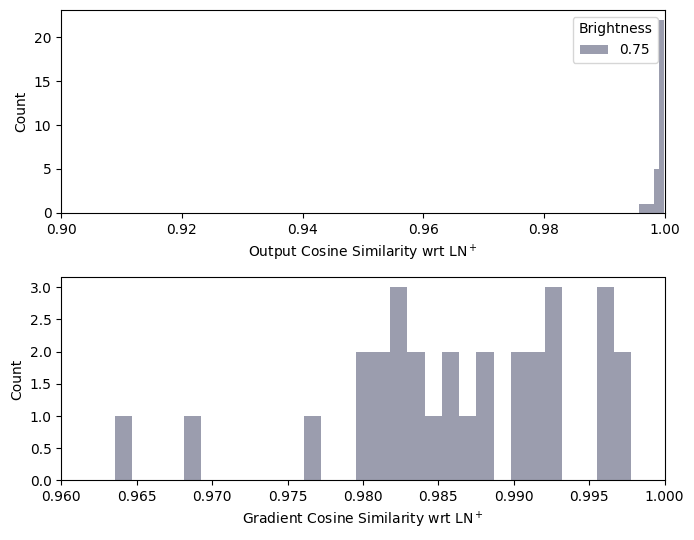

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm, colors

# -------------------------
# Helpers
# -------------------------

def truncate_colormap(cmap, minval=0.0, maxval=0.85, n=100):
    return colors.LinearSegmentedColormap.from_list(
        f"trunc({cmap.name},{minval:.2f},{maxval:.2f})",
        cmap(np.linspace(minval, maxval, n))
    )

def safe_float(x):
    """Convert x to float if possible, otherwise return None."""
    try:
        v = float(x)
        if np.isnan(v):
            return None
        return v
    except Exception:
        return None

brightness_factors = [0.75] #, 0.25, 0.5, 0.75]
layers_to_average = ["fc0", "fc1"]

trunc_bone = truncate_colormap(cm.get_cmap("bone"), 0.4, 0.9)
norm = colors.Normalize(vmin=min(brightness_factors), vmax=max(brightness_factors))


# -------------------------
# Data collection
# -------------------------

def collect_last_epoch_summary(alignment_prefix):
    """Collect last-epoch summary values and average across layers."""
    brightness_to_values = {}

    for bright in brightness_factors:
        run_values = []

        runs = fetch_runs(
            api,
            entity='royeyono',
            project_name='Luminosity_LNHomeostasis',
            filters={
                "config.dataset": "fashionmnist_contrast",
                "config.brightness_factor": bright,
                "config.homeostasis": 1,
                "config.normtype_detach": 0,
                "config.excitation_training": 1,
                "config.layer_norm": 0,
                "config.use_testset": True,
                "config.ln_feedback": 'full',
            },
            order="-summary_metrics.test_acc"
        )

        for run in runs:
            layer_vals = []

            for layer in layers_to_average:
                key = f"{alignment_prefix}{layer}"

                if key not in run.summary:
                    continue

                val = safe_float(run.summary[key])
                if val is not None:
                    layer_vals.append(val)

            if len(layer_vals) > 0:
                run_values.append(np.mean(layer_vals))

        if len(run_values) > 0:
            brightness_to_values[bright] = np.array(run_values)

    return brightness_to_values


# Collect both datasets
output_data = collect_last_epoch_summary("output_alignment_")
grad_data   = collect_last_epoch_summary("gradient_alignment_")


# -------------------------
# Plotting (subplots)
# -------------------------

fig, axes = plt.subplots(2, 1, figsize=(7, 5.5), sharex=False)

# --- Top: Output alignment ---
ax = axes[0]
for bright, values in output_data.items():
    ax.hist(values, bins=5, alpha=0.6,
            color=trunc_bone(norm(bright)), label=str(bright))

ax.set_xlabel("Output Cosine Similarity wrt LN$^+$")
ax.set_ylabel("Count")
ax.legend(title="Brightness")
ax.set_xlim(0.90, 1)
# ax.set_yscale('log')

# --- Bottom: Gradient alignment ---
ax = axes[1]
for bright, values in grad_data.items():
    ax.hist(values, bins=30, alpha=0.6,
            color=trunc_bone(norm(bright)),
            # rwidth=0.9,
            label=str(bright))

ax.set_xlabel("Gradient Cosine Similarity wrt LN$^+$")
ax.set_ylabel("Count")
# ax.set_xlim(0.90, 1)
ax.set_xlim(0.96, 1)
# ax.set_yscale('log')

plt.tight_layout()
plt.show()


In [11]:
fig, ax = plt.subplots(figsize=(6,5))

# Example brightness factors used
brightness_values = [0, 0.25, 0.5, 0.75]

# Normalize brightness for colormap mapping
norm = mcolors.Normalize(vmin=min(brightness_values), vmax=max(brightness_values))

def truncate_colormap(cmap, minval=0.2, maxval=1.0, n=256):
    new_cmap = mcolors.LinearSegmentedColormap.from_list(
        f'trunc({cmap.name},{minval:.2f},{maxval:.2f})',
        cmap(np.linspace(minval, maxval, n))
    )
    return new_cmap

# Create a grayscale colormap from 20% (dark gray) to 100% (black)
cmap = truncate_colormap(plt.get_cmap('bone'), 0.2, 0.7)

scatter_handles = []  # For legend proxy if needed

list_line = range(100)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.plot(list_line, list_line, color='black', linestyle='--')
ax.set_ylabel(f"I-Norm /w GradNorm (Acc. %)", fontsize=20)
ax.set_xlabel("LN$^+$ (Acc. %)", fontsize=20)

for bfi in brightness_values:
    color = cmap(norm(bfi))

    runs_dict = dict()

    runs_dict["runs_vanilla_dann_layernorm"] = fetch_runs(api, entity='royeyono', project_name='Luminosity_LNHomeostasis', filters={"config.dataset": "fashionmnist", 
                                                            "config.brightness_factor": bfi, "config.homeostasis": 0, "config.normtype_detach": 0,
                                                            "config.excitation_training": 1, "config.layer_norm": 1, "config.use_testset": True}, order="-summary_metrics.test_acc")
    runs_dict["runs_homeostasis"] = fetch_runs(api, entity='royeyono', project_name='Luminosity_LNHomeostasis', filters={"config.dataset": "fashionmnist", 
                                                            "config.brightness_factor": bfi, "config.homeostasis": 1, "config.normtype_detach": 0,
                                                            "config.excitation_training": 1, "config.layer_norm": 0, "config.use_testset": True, "config.ln_feedback":'full'}, order="-summary_metrics.test_acc")

    top_n = len(runs_dict["runs_vanilla_dann_layernorm"])

    for top in range(top_n):
        vanilla_dann_acc = runs_dict["runs_vanilla_dann_layernorm"][top].summary['test_acc']
        for rn in runs_dict["runs_homeostasis"]:
            if same_config(rn.config, runs_dict["runs_vanilla_dann_layernorm"][top].config, keys=['lr', 'wd','inhib_lrs', 'momentum', 'inhib_momentum']):
                sc = ax.scatter( vanilla_dann_acc, rn.summary['test_acc'], color=color, label=f"$\epsilon$={bfi}" if top == 0 else None)
                break  # Only label once per brightness group
ax.set_xlim(82.5, 90)
ax.set_ylim(82.5, 90)
# ax.set_xlim(85, 90)
# ax.set_ylim(85, 90)
ax.legend()
sm = cm.ScalarMappable(cmap=cmap, norm=norm)

<>:46: SyntaxWarning: invalid escape sequence '\e'
<>:46: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_3549160/3099301345.py:46: SyntaxWarning: invalid escape sequence '\e'
  sc = ax.scatter( vanilla_dann_acc, rn.summary['test_acc'], color=color, label=f"$\epsilon$={bfi}" if top == 0 else None)


In [5]:
from pathlib import Path


def safe_float(x):
    """Convert x to float if possible, otherwise return None."""
    try:
        v = float(x)
        if np.isnan(v):
            return None
        return v
    except Exception:
        return None


ALIGNMENT_EPSILONS = (0.0, 0.25, 0.5, 0.75)
ALIGNMENT_TASKS = {
    "Brightness": "fashionmnist",
    "Contrast": "fashionmnist_contrast",
}
ALIGNMENT_LAYERS = ("fc0", "fc1")
ALIGNMENT_MATCH_KEYS = (
    "lr",
    "wd",
    "inhib_lrs",
    "momentum",
    "inhib_momentum",
)


def _freeze_alignment_config(value):
    """Convert nested W&B config values into a stable hashable form."""
    if isinstance(value, dict):
        return tuple(sorted(
            (key, _freeze_alignment_config(item))
            for key, item in value.items()
        ))
    if isinstance(value, (list, tuple)):
        return tuple(_freeze_alignment_config(item) for item in value)
    if isinstance(value, set):
        return tuple(sorted(_freeze_alignment_config(item) for item in value))
    if hasattr(value, "tolist"):
        return _freeze_alignment_config(value.tolist())
    try:
        hash(value)
        return value
    except TypeError:
        return repr(value)


def _alignment_config_key(run):
    return tuple(
        (key, _freeze_alignment_config(run.config.get(key)))
        for key in ALIGNMENT_MATCH_KEYS
    )


def collect_alignment_by_detach(alignment_prefix, normtype_detach):
    """Collect one value per layer, unique config, task, and epsilon."""
    collected = {task: {} for task in ALIGNMENT_TASKS}

    for task, dataset in ALIGNMENT_TASKS.items():
        for epsilon in ALIGNMENT_EPSILONS:
            runs = fetch_runs(
                api,
                entity="royeyono",
                project_name="Luminosity_LNHomeostasis",
                filters={
                    "config.dataset": dataset,
                    "config.brightness_factor": epsilon,
                    "config.homeostasis": 1,
                    "config.normtype_detach": normtype_detach,
                    "config.shunting": 1,
                    "config.excitation_training": 1,
                    "config.layer_norm": 0,
                    "config.use_testset": True,
                    "config.ln_feedback": "full",
                },
                order="-summary_metrics.test_acc",
            )

            values_by_config_and_layer = {}
            for run in runs:
                config_key = _alignment_config_key(run)
                for layer in ALIGNMENT_LAYERS:
                    value = safe_float(
                        run.summary.get(f"{alignment_prefix}{layer}")
                    )
                    if value is not None:
                        values_by_config_and_layer.setdefault(
                            (config_key, layer),
                            value,
                        )

            collected[task][epsilon] = np.asarray(
                list(values_by_config_and_layer.values()), dtype=float
            )

    return collected


def pool_series(grid, epsilon):
    """Pool brightness and contrast runs for one epsilon."""
    chunks = [
        grid[task][epsilon]
        for task in ALIGNMENT_TASKS
        if grid[task][epsilon].size
    ]
    if not chunks:
        return np.asarray([], dtype=float)
    return np.concatenate(chunks)


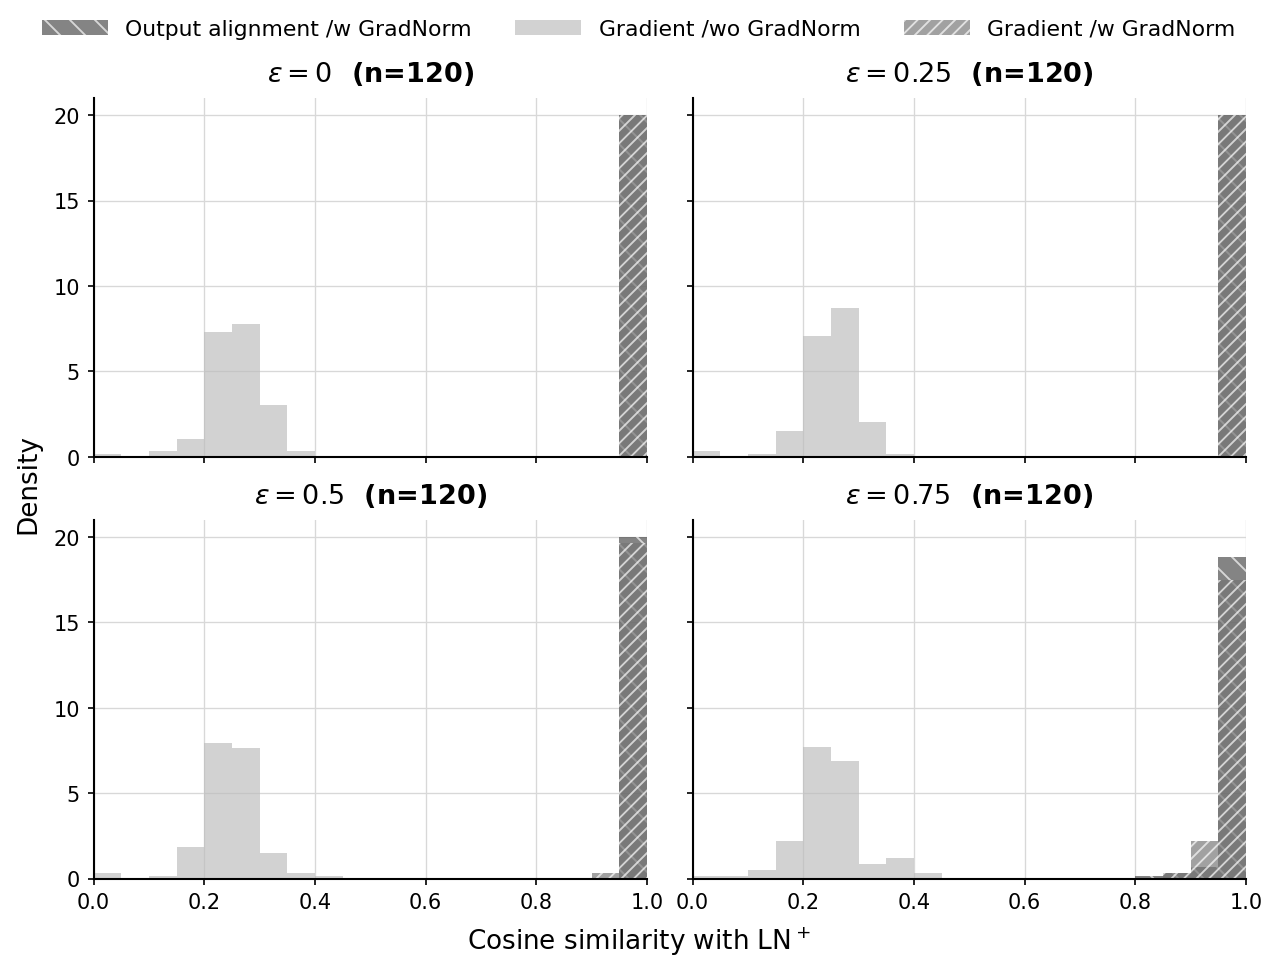

SVG saved to: /home/mila/r/roy.eyono/RNN_EI_Network/experiments/dense_fmnist/analysis/fig_5_alignment_by_epsilon.svg
epsilon=0: pooled n = {'Output alignment /w GradNorm': 120, 'Gradient /wo GradNorm': 120, 'Gradient /w GradNorm': 120}
epsilon=0.25: pooled n = {'Output alignment /w GradNorm': 120, 'Gradient /wo GradNorm': 120, 'Gradient /w GradNorm': 120}
epsilon=0.5: pooled n = {'Output alignment /w GradNorm': 120, 'Gradient /wo GradNorm': 120, 'Gradient /w GradNorm': 120}
epsilon=0.75: pooled n = {'Output alignment /w GradNorm': 120, 'Gradient /wo GradNorm': 120, 'Gradient /w GradNorm': 120}


In [6]:
# Alignment across tasks and epsilon: output + gradient (/wo and /w GradNorm).
# Brightness and contrast are pooled, while fc0 and fc1 remain separate
# observations (30 configs x 2 tasks x 2 layers = n=120 per series).
output_grid = collect_alignment_by_detach("output_alignment_", 0)
grad_wo_grid = collect_alignment_by_detach("gradient_alignment_", 1)
grad_w_grid = collect_alignment_by_detach("gradient_alignment_", 0)

# (label, grid, facecolor, hatch or None)
SERIES = [
    ("Output alignment /w GradNorm", output_grid, "#4A4A4A", "\\\\"),
    ("Gradient /wo GradNorm", grad_wo_grid, "#BDBDBD", None),
    ("Gradient /w GradNorm", grad_w_grid, "#757575", "////"),
]

alignment_bins = np.linspace(0.0, 1.0, 21)

with plt.rc_context({
    "font.family": "DejaVu Sans",
    "font.size": 10.5,
    "figure.dpi": 150,
    "axes.titlesize": 13,
    "axes.titleweight": "semibold",
    "axes.labelsize": 11,
    "axes.linewidth": 1.0,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "hatch.linewidth": 0.9,
}):
    fig, axes = plt.subplots(
        2, 2,
        figsize=(8.4, 6.4),
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )

    for ax, epsilon in zip(axes.flat, ALIGNMENT_EPSILONS):
        for label, grid, color, hatch in SERIES:
            pooled = pool_series(grid, epsilon)
            if pooled.size == 0:
                continue
            hist_kwargs = dict(
                bins=alignment_bins,
                density=True,
                histtype="stepfilled",
                facecolor=color,
                alpha=0.68,
                label=label,
            )
            if hatch:
                hist_kwargs.update(
                    hatch=hatch,
                    edgecolor="white",
                    linewidth=0.0,
                )
            else:
                hist_kwargs["edgecolor"] = "none"
            ax.hist(pooled, **hist_kwargs)

        sample_count = pool_series(output_grid, epsilon).size
        ax.set_title(rf"$\epsilon={epsilon:g}$  (n={sample_count})", pad=8)
        ax.set_xlim(0.0, 1.0)
        ax.grid(color="#D8D8D8", linewidth=0.65)
        ax.set_axisbelow(True)
        ax.spines[["top", "right"]].set_visible(False)
        ax.tick_params(length=3, width=0.8, color="black")

    fig.supxlabel(r"Cosine similarity with LN$^+$")
    fig.supylabel("Density")
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="outside upper center",
        ncol=3,
        frameon=False,
        handlelength=3.0,
    )

    output_path = Path("fig_5_alignment_by_epsilon.svg").resolve()
    fig.savefig(
        output_path,
        format="svg",
        bbox_inches="tight",
        pad_inches=0.06,
        facecolor="white",
        edgecolor="none",
    )
    plt.show()

print(f"SVG saved to: {output_path}")
for epsilon in ALIGNMENT_EPSILONS:
    counts = {
        label: pool_series(grid, epsilon).size
        for label, grid, _, _ in SERIES
    }
    print(f"epsilon={epsilon:g}: pooled n = {counts}")



In [17]:
# Pooled accuracy comparison across tasks and epsilon values (I-Norm + GradNorm vs LN+)
from collections import defaultdict, deque

ACCURACY_MATCH_KEYS = (
    "lr",
    "wd",
    "inhib_lrs",
    "momentum",
    "inhib_momentum",
)


def _freeze_accuracy_config(value):
    """Convert nested W&B config values into stable, hashable objects."""
    if isinstance(value, dict):
        return tuple(sorted(
            (key, _freeze_accuracy_config(item))
            for key, item in value.items()
        ))
    if isinstance(value, (list, tuple)):
        return tuple(_freeze_accuracy_config(item) for item in value)
    if isinstance(value, set):
        return tuple(sorted(_freeze_accuracy_config(item) for item in value))
    if hasattr(value, "tolist"):
        return _freeze_accuracy_config(value.tolist())
    try:
        hash(value)
        return value
    except TypeError:
        return repr(value)


def _accuracy_config_key(run):
    return tuple(
        _freeze_accuracy_config(run.config.get(key))
        for key in ACCURACY_MATCH_KEYS
    )


def _fetch_accuracy_runs(dataset, epsilon, method):
    common_filters = {
        "config.dataset": dataset,
        "config.brightness_factor": epsilon,
        "config.excitation_training": 1,
        "config.use_testset": True,
    }
    if method == "LN+":
        method_filters = {
            "config.homeostasis": 0,
            "config.normtype_detach": 0,
            "config.layer_norm": 1,
        }
    elif method == "I-Norm+GradNorm":
        method_filters = {
            "config.homeostasis": 1,
            "config.normtype_detach": 0,
            "config.layer_norm": 0,
            "config.ln_feedback": "full",
        }
    else:
        raise ValueError(f"Unknown method: {method}")

    return list(fetch_runs(
        api,
        entity="royeyono",
        project_name="Luminosity_LNHomeostasis",
        filters={**common_filters, **method_filters},
        order="-summary_metrics.test_acc",
    ))


def collect_matched_pooled_accuracies():
    """Pair configurations one-to-one, grouped by epsilon and pooled over tasks."""
    pooled = {"I-Norm+GradNorm": [], "LN+": []}
    by_epsilon = {
        epsilon: {"I-Norm+GradNorm": [], "LN+": []}
        for epsilon in ALIGNMENT_EPSILONS
    }
    matched_counts = {}

    for task, dataset in ALIGNMENT_TASKS.items():
        for epsilon in ALIGNMENT_EPSILONS:
            ln_runs = _fetch_accuracy_runs(dataset, epsilon, "LN+")
            inorm_runs = _fetch_accuracy_runs(dataset, epsilon, "I-Norm+GradNorm")

            inorm_by_config = defaultdict(deque)
            for run in inorm_runs:
                accuracy = safe_float(run.summary.get("test_acc"))
                if accuracy is not None:
                    inorm_by_config[_accuracy_config_key(run)].append(accuracy)

            condition_pairs = []
            for run in ln_runs:
                accuracy = safe_float(run.summary.get("test_acc"))
                matches = inorm_by_config[_accuracy_config_key(run)]
                if accuracy is not None and matches:
                    condition_pairs.append((matches.popleft(), accuracy))

            matched_counts[task, epsilon] = len(condition_pairs)
            pooled["I-Norm+GradNorm"].extend(pair[0] for pair in condition_pairs)
            pooled["LN+"].extend(pair[1] for pair in condition_pairs)
            by_epsilon[epsilon]["I-Norm+GradNorm"].extend(
                pair[0] for pair in condition_pairs
            )
            by_epsilon[epsilon]["LN+"].extend(
                pair[1] for pair in condition_pairs
            )

    pooled = {
        method: np.asarray(values, dtype=float)
        for method, values in pooled.items()
    }
    by_epsilon = {
        epsilon: {
            method: np.asarray(values, dtype=float)
            for method, values in methods.items()
        }
        for epsilon, methods in by_epsilon.items()
    }
    return pooled, by_epsilon, matched_counts


(
    pooled_accuracy,
    accuracy_by_epsilon,
    matched_accuracy_counts,
) = collect_matched_pooled_accuracies()
if not all(values.size for values in pooled_accuracy.values()):
    raise RuntimeError(
        "No matched I-Norm+GradNorm/LN+ accuracy pairs were found; check the W&B filters."
    )

combined_accuracy = np.concatenate(list(pooled_accuracy.values()))
accuracy_span = np.ptp(combined_accuracy)
accuracy_pad = 0.05 * accuracy_span if accuracy_span else 0.5
accuracy_limits = (
    combined_accuracy.min() - accuracy_pad,
    combined_accuracy.max() + accuracy_pad,
)

with plt.rc_context({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "figure.dpi": 150,
    "axes.titlesize": 12,
    "axes.titleweight": "semibold",
    "axes.labelsize": 12,
    "axes.linewidth": 1.0,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
}):
    fig, axes = plt.subplots(
        2, 2,
        figsize=(8.0, 7.6),
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )

    for ax, epsilon in zip(axes.flat, ALIGNMENT_EPSILONS):
        epsilon_accuracy = accuracy_by_epsilon[epsilon]
        ax.plot(
            accuracy_limits,
            accuracy_limits,
            color="black",
            linestyle="--",
            linewidth=1.1,
            zorder=1,
        )
        ax.scatter(
            epsilon_accuracy["LN+"],
            epsilon_accuracy["I-Norm+GradNorm"],
            s=28,
            facecolor="white",
            edgecolor="black",
            linewidth=0.75,
            alpha=0.72,
            zorder=2,
        )
        ax.set(
            xlim=accuracy_limits,
            ylim=accuracy_limits,
            title=rf"$\epsilon={epsilon:g}$  "
                  f"(n={epsilon_accuracy['I-Norm+GradNorm'].size})",
        )
        ax.set_aspect("equal", adjustable="box")
        ax.grid(color="#D8D8D8", linewidth=0.7)
        ax.set_axisbelow(True)
        ax.spines[["top", "right"]].set_visible(False)
        ax.tick_params(length=3, width=0.8, color="black")

    fig.supxlabel(r"LN$^+$ test accuracy (%)")
    fig.supylabel("I-Norm /w GradNorm test accuracy (%)")

    accuracy_output_path = Path("fig_5_accuracy_by_epsilon.svg").resolve()
    fig.savefig(
        accuracy_output_path,
        format="svg",
        bbox_inches="tight",
        pad_inches=0.06,
        facecolor="white",
        edgecolor="none",
    )
    plt.close(fig)

print(f"SVG saved to: {accuracy_output_path}")
print(f"Total matched pairs: {pooled_accuracy['I-Norm+GradNorm'].size}")
for task in ALIGNMENT_TASKS:
    counts = [
        matched_accuracy_counts[task, epsilon]
        for epsilon in ALIGNMENT_EPSILONS
    ]
    print(f"{task:>10}: matched n by epsilon = {counts}")
for epsilon in ALIGNMENT_EPSILONS:
    n = accuracy_by_epsilon[epsilon]["I-Norm+GradNorm"].size
    print(f"epsilon={epsilon:g}: pooled matched n = {n}")


SVG saved to: /home/mila/r/roy.eyono/RNN_EI_Network/experiments/dense_fmnist/analysis/fig_5_accuracy_by_epsilon.svg
Total matched pairs: 240
Brightness: matched n by epsilon = [30, 30, 30, 30]
  Contrast: matched n by epsilon = [30, 30, 30, 30]
epsilon=0: pooled matched n = 60
epsilon=0.25: pooled matched n = 60
epsilon=0.5: pooled matched n = 60
epsilon=0.75: pooled matched n = 60
